In [ ]:
!pip install timm scikit-learn tqdm seaborn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import timm
import numpy as np
import cv2
import optuna
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/ML/dataset/stage2_disease_classifier"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR = os.path.join(DATASET_PATH,"test")

MODEL_PATH = "/content/drive/MyDrive/ML/models"

os.makedirs(MODEL_PATH,exist_ok=True)

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(30),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.RandomAffine(
        degrees=20,
        translate=(0.1,0.1)
    ),

    transforms.ToTensor()

])

test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()

])

In [ ]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)

test_dataset = ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32)

print(train_dataset.classes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
resnet = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=3
).to(device)

efficientnet = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=3
).to(device)

densenet = timm.create_model(
    "densenet121",
    pretrained=True,
    num_classes=3
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer_resnet = optim.AdamW(resnet.parameters(),lr=3e-4,weight_decay=1e-4)
optimizer_eff = optim.AdamW(efficientnet.parameters(),lr=3e-4,weight_decay=1e-4)
optimizer_dense = optim.AdamW(densenet.parameters(),lr=3e-4,weight_decay=1e-4)

In [ ]:
def train_model(model, optimizer, epochs=8):

    train_acc=[]
    train_loss=[]

    for epoch in range(epochs):

        model.train()

        correct=0
        total=0
        running_loss=0

        for images,labels in tqdm(train_loader):

            images=images.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss+=loss.item()

            _,pred=torch.max(outputs,1)

            total+=labels.size(0)
            correct+=(pred==labels).sum().item()

        acc=correct/total

        train_acc.append(acc)
        train_loss.append(running_loss)

        print("Epoch:",epoch+1,"Accuracy:",acc)

    return train_acc,train_loss

In [ ]:
print("Training ResNet50")
resnet_acc,resnet_loss=train_model(resnet,optimizer_resnet)

print("Training EfficientNet")
eff_acc,eff_loss=train_model(efficientnet,optimizer_eff)

print("Training DenseNet")
dense_acc,dense_loss=train_model(densenet,optimizer_dense)

Training ResNet50


100%|██████████| 15/15 [01:31<00:00,  6.13s/it]


Epoch: 1 Accuracy: 0.5592105263157895


100%|██████████| 15/15 [00:08<00:00,  1.87it/s]


Epoch: 2 Accuracy: 0.9057017543859649


...

Epoch: 6 Accuracy: 0.993421052631579


100%|██████████| 15/15 [00:08<00:00,  1.78it/s]


Epoch: 7 Accuracy: 0.9956140350877193


100%|██████████| 15/15 [00:07<00:00,  1.89it/s]

Epoch: 8 Accuracy: 0.9912280701754386


In [ ]:
def extract_features(model, dataloader):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for images, target in tqdm(dataloader):

            images = images.to(device)

            # Extract backbone features
            output = model.forward_features(images)

            # Handle different tensor shapes
            if len(output.shape) == 4:
                # shape = [B, C, H, W]
                output = torch.mean(output, dim=[2,3])

            elif len(output.shape) == 3:
                # shape = [B, Tokens, C] (ViT-like)
                output = torch.mean(output, dim=1)

            # else shape already [B, C]

            features.append(output.cpu().numpy())

            labels.extend(target.numpy())

    features = np.concatenate(features)

    return features, np.array(labels)

In [ ]:
X_train, y_train = extract_features(resnet, train_loader)

100%|██████████| 15/15 [00:05<00:00,  2.79it/s]


In [ ]:
X_test, y_test = extract_features(resnet, test_loader)

100%|██████████| 15/15 [02:06<00:00,  8.44s/it]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
def svm_objective(trial):

    # Hyperparameters to search
    C = trial.suggest_float("C", 1e-3, 10, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "poly"])

    svm = SVC(
        C=C,
        gamma=gamma,
        kernel=kernel,
        probability=True
    )

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        svm.fit(X_tr, y_tr)

        preds = svm.predict(X_val)

        acc = accuracy_score(y_val, preds)

        scores.append(acc)

    return np.mean(scores)

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(svm_objective, n_trials=30)

[I 2026-03-15 13:54:10,961] A new study created in memory with name: no-name-9d41228b-eff8-40ab-90e8-d7cc2dfb2baf
[I 2026-03-15 13:54:12,292] Trial 0 finished with value: 1.0 and parameters: {'C': 8.391024561272587, 'gamma': 0.043419318817386414, 'kernel': 'poly'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:54:16,438] Trial 1 finished with value: 0.5904921165790731 and parameters: {'C': 0.001476143606800424, 'gamma': 0.0001242861439311317, 'kernel': 'rbf'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:54:17,848] Trial 2 finished with value: 1.0 and parameters: {'C': 0.04641844253274243, 'gamma': 0.004356496293017949, 'kernel': 'poly'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:54:19,261] Trial 3 finished with value: 1.0 and parameters: {'C': 8.397664062466985, 'gamma': 0.004229255134818718, 'kernel': 'poly'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:54:20,669] Trial 4 finished with value: 1.0 and parameters: {'C': 0.05603294158728635, 'gamma': 0.09019264818

In [ ]:
best_params = study.best_params

print("Best Parameters:", best_params)

Best Parameters: {'C': 8.391024561272587, 'gamma': 0.043419318817386414, 'kernel': 'poly'}


In [ ]:
svm_model = SVC(
    **best_params,
    probability=True
)

svm_model.fit(X_train, y_train)

SVC(C=8.391024561272587, gamma=0.043419318817386414, kernel='poly',
    probability=True)

In [ ]:
from sklearn.metrics import classification_report

svm_pred = svm_model.predict(X_test)

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       152
           1       0.99      0.99      0.99       152
           2       0.99      0.99      0.99       152

    accuracy                           0.99       456
   macro avg       0.99      0.99      0.99       456
weighted avg       0.99      0.99      0.99       456



In [ ]:
svm_pred = svm_model.predict(X_test)

svm_prob = svm_model.predict_proba(X_test)

In [ ]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

n_classes = 3

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        svm_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

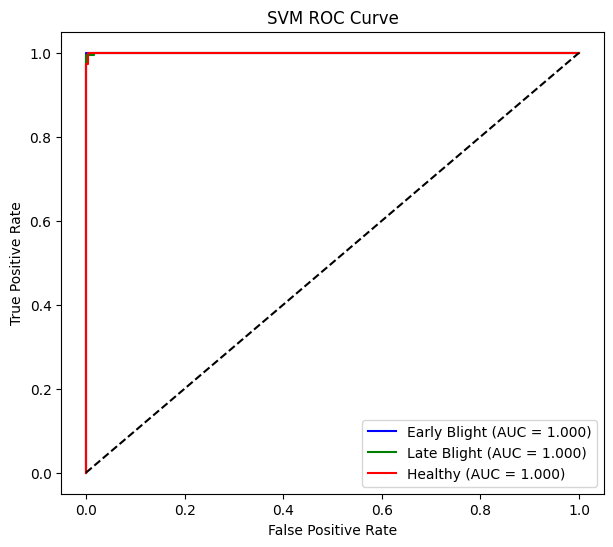

In [ ]:
plt.figure(figsize=(7,6))

colors = ["blue","green","red"]

class_names = [
"Early Blight",
"Late Blight",
"Healthy"
]

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.legend()

plt.show()

In [ ]:
def rf_objective(trial):

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    max_depth = trial.suggest_int("max_depth", 5, 30)

    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        rf.fit(X_tr, y_tr)

        preds = rf.predict(X_val)

        acc = accuracy_score(y_val, preds)

        scores.append(acc)

    return np.mean(scores)

In [ ]:
svm_auc = roc_auc_score(
    y_test_bin,
    svm_prob,
    multi_class="ovr"
)

print("Overall SVM ROC AUC:", svm_auc)

Overall SVM ROC AUC: 0.9999350761772853


In [ ]:
rf_study = optuna.create_study(direction="maximize")

rf_study.optimize(rf_objective, n_trials=30)

[I 2026-03-15 13:55:15,398] A new study created in memory with name: no-name-92ea246b-3237-4445-88ca-524992c5ad3b
[I 2026-03-15 13:55:24,157] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 374, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:55:34,646] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 492, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:55:40,272] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 451, 'max_depth': 29, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 1.0.
[I 2026-03-15 13:55:50,866] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 479, 'max_depth': 23, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 1.0.
[I 

In [ ]:
best_rf_params = rf_study.best_params

print("Best RF Parameters:", best_rf_params)

Best RF Parameters: {'n_estimators': 374, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [ ]:
rf_model = RandomForestClassifier(

    **best_rf_params,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=3,
                       min_samples_split=9, n_estimators=374, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

rf_pred = rf_model.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      0.99      0.99       152
           2       0.99      1.00      0.99       152

    accuracy                           1.00       456
   macro avg       1.00      1.00      1.00       456
weighted avg       1.00      1.00      1.00       456



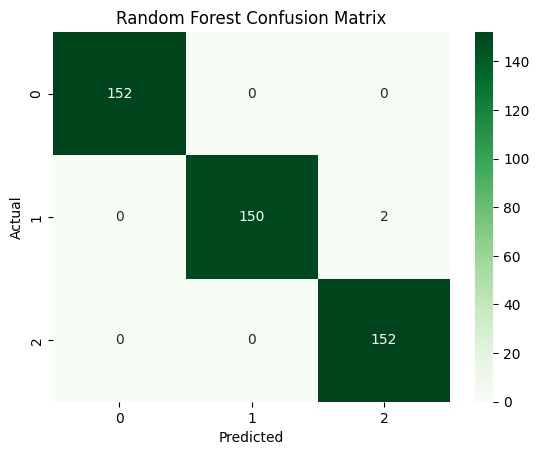

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, cmap="Greens", fmt="d")

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)

y_test_bin = label_binarize(y_test, classes=[0,1,2])

rf_auc = roc_auc_score(y_test_bin, rf_prob, multi_class="ovr")

print("Random Forest ROC AUC:", rf_auc)

Random Forest ROC AUC: 0.9999927862419206


In [ ]:
def ensemble_predict(images):

    images = images.to(device)

    resnet.eval()
    efficientnet.eval()
    densenet.eval()

    with torch.no_grad():

        # CNN Predictions
        p1 = torch.softmax(resnet(images), dim=1).cpu().numpy()
        p2 = torch.softmax(efficientnet(images), dim=1).cpu().numpy()
        p3 = torch.softmax(densenet(images), dim=1).cpu().numpy()

        # Feature extraction (same as training)
        features = resnet.forward_features(images)

        if len(features.shape) == 4:
            features = torch.mean(features, dim=[2,3])

        features = features.cpu().numpy()

    # Apply scaler if used
    if 'scaler' in globals():
        features = scaler.transform(features)

    # ML model predictions
    p4 = svm_model.predict_proba(features)
    p5 = rf_model.predict_proba(features)

    # Ensemble (soft voting)
    final = (p1 + p2 + p3 + p4 + p5) / 5

    return final

In [ ]:
def evaluate_cnn_model(model, dataloader, model_name):

    model.eval()

    y_true=[]
    y_pred=[]
    y_prob=[]

    with torch.no_grad():

        for images,labels in dataloader:

            images=images.to(device)

            outputs=model(images)

            probs=torch.softmax(outputs,1).cpu().numpy()

            preds=np.argmax(probs,axis=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    y_prob=np.array(y_prob)

    print("\n=======================")
    print(model_name)
    print("=======================")

    print(classification_report(y_true,y_pred))

    # Confusion Matrix
    cm=confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,cmap="Blues",fmt="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC AUC

    y_true_bin=label_binarize(y_true,classes=[0,1,2])

    fpr={}
    tpr={}
    roc_auc={}

    for i in range(3):

        fpr[i],tpr[i],_=roc_curve(y_true_bin[:,i],y_prob[:,i])
        roc_auc[i]=auc(fpr[i],tpr[i])

    plt.figure()

    for i in range(3):

        plt.plot(fpr[i],tpr[i],label=f"Class {i} AUC={roc_auc[i]:.2f}")

    plt.plot([0,1],[0,1],'k--')

    plt.title(f"{model_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

    return roc_auc_score(y_true_bin,y_prob,average="macro")


ResNet50
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      0.97      0.98       152
           2       0.97      1.00      0.98       152

    accuracy                           0.99       456
   macro avg       0.99      0.99      0.99       456
weighted avg       0.99      0.99      0.99       456



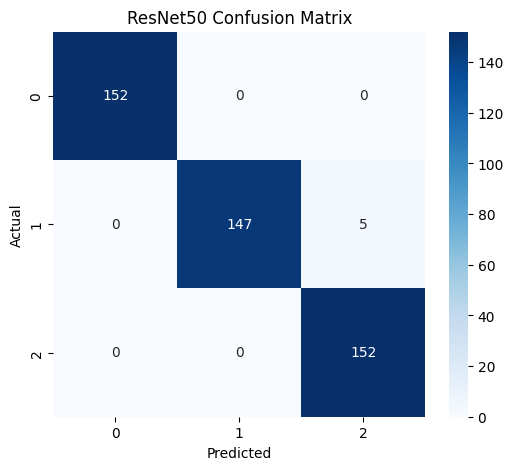

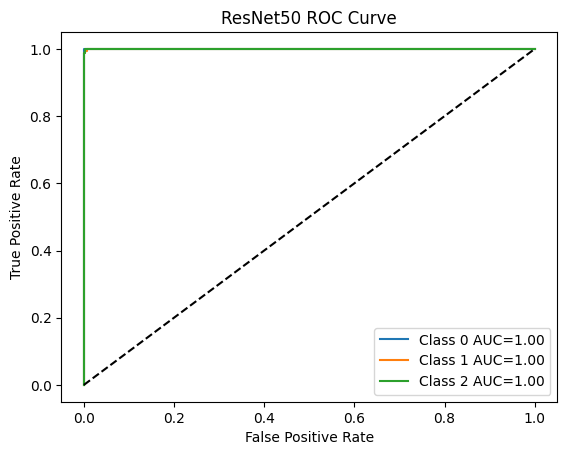


EfficientNetB4
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       152
           1       0.93      0.94      0.93       152
           2       0.93      0.96      0.94       152

    accuracy                           0.95       456
   macro avg       0.95      0.95      0.95       456
weighted avg       0.95      0.95      0.95       456



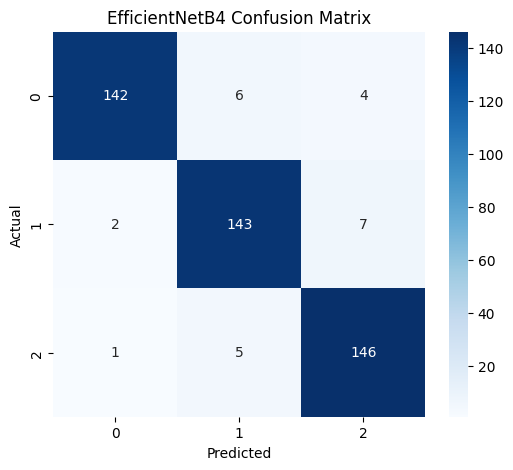

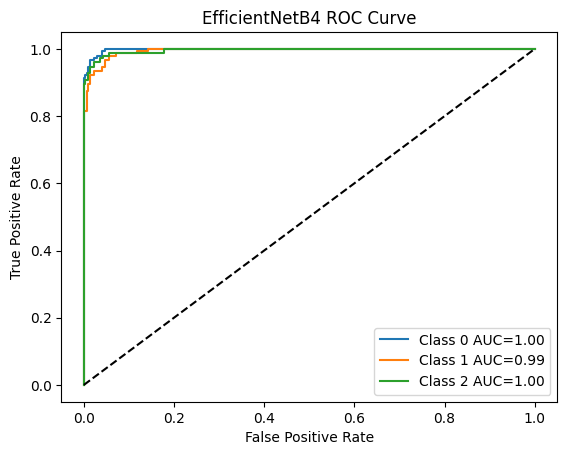


DenseNet121
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      0.99      0.99       152
           2       0.99      1.00      0.99       152

    accuracy                           1.00       456
   macro avg       1.00      1.00      1.00       456
weighted avg       1.00      1.00      1.00       456



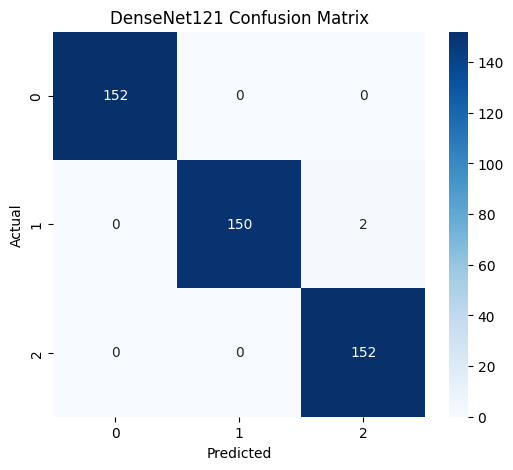

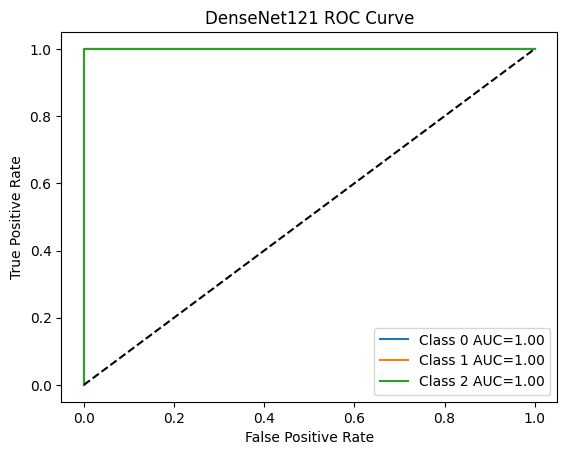

In [ ]:
resnet_auc = evaluate_cnn_model(resnet,test_loader,"ResNet50")

efficientnet_auc = evaluate_cnn_model(efficientnet,test_loader,"EfficientNetB4")

densenet_auc = evaluate_cnn_model(densenet,test_loader,"DenseNet121")

In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_loader:

    probs = ensemble_predict(images)

    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

In [ ]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       152
           1       1.00      0.99      0.99       152
           2       0.99      1.00      0.99       152

    accuracy                           1.00       456
   macro avg       1.00      1.00      1.00       456
weighted avg       1.00      1.00      1.00       456



In [ ]:
y_prob=np.array(y_prob)

roc_auc=roc_auc_score(y_true,y_prob,multi_class="ovr")

print("ROC AUC:",roc_auc)

ROC AUC: 0.9999855724838412


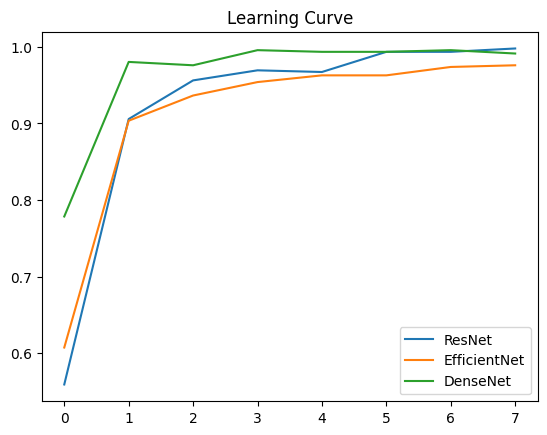

In [ ]:
plt.plot(resnet_acc,label="ResNet")

plt.plot(eff_acc,label="EfficientNet")

plt.plot(dense_acc,label="DenseNet")

plt.legend()

plt.title("Learning Curve")

plt.show()

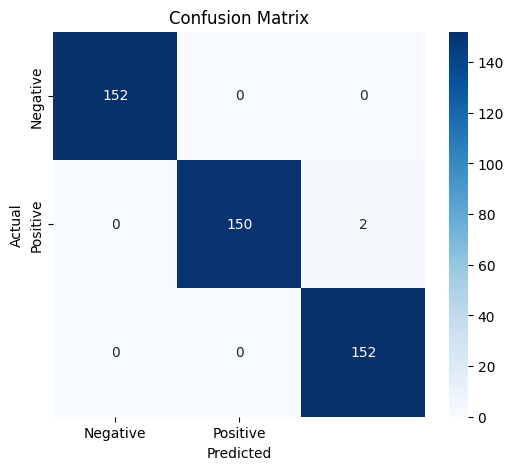

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
MODEL_SAVE = f"{MODEL_PATH}/stage2_ensemble_model.pt"

ensemble_package = {

    "svm_model": svm_model,

    "rf_model": rf_model,

    "resnet_weights": resnet.state_dict(),

    "efficientnet_weights": efficientnet.state_dict(),

    "densenet_weights": densenet.state_dict(),

    "class_names": train_dataset.classes,

}

# Save scaler if used
if 'scaler' in globals():
    ensemble_package["scaler"] = scaler

joblib.dump(ensemble_package, MODEL_SAVE)

print("Model saved at:", MODEL_SAVE)

Model saved at: /content/drive/MyDrive/ML/models/stage2_ensemble_model.pt


In [ ]:
class_names = train_dataset.classes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model_predict_fn, dataloader, num_images=12):

    images_shown = 0

    plt.figure(figsize=(12,10))

    for images, labels in dataloader:

        probs = model_predict_fn(images)

        preds = np.argmax(probs, axis=1)

        for i in range(len(images)):

            img = images[i].permute(1,2,0).numpy()

            actual = class_names[labels[i]]

            predicted = class_names[preds[i]]

            plt.subplot(3,4,images_shown+1)

            plt.imshow(img)

            if actual == predicted:
                color = "green"
            else:
                color = "red"

            plt.title(f"A: {actual}\nP: {predicted}", color=color)

            plt.axis("off")

            images_shown += 1

            if images_shown == num_images:
                plt.tight_layout()
                plt.show()
                return

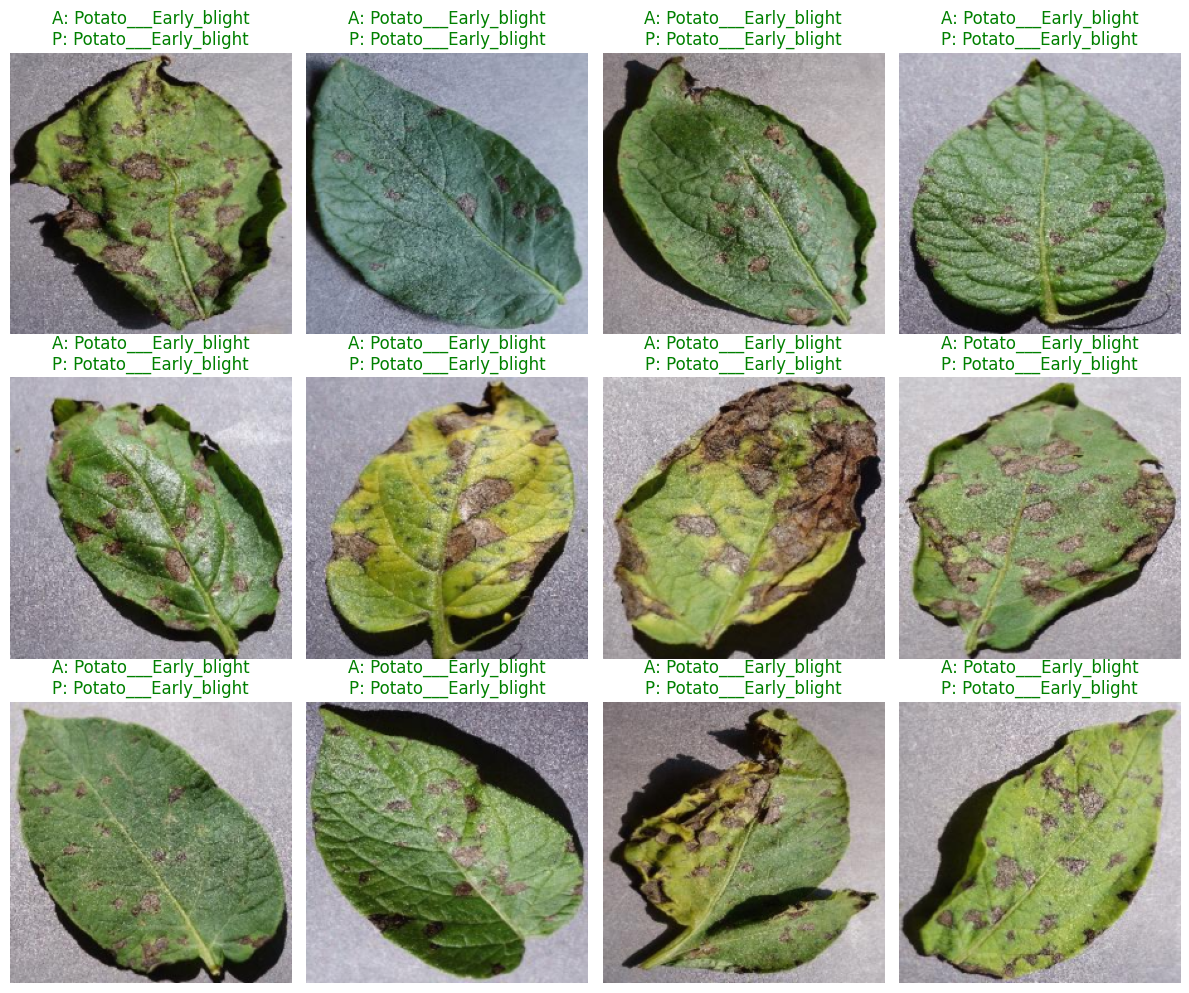

In [ ]:
visualize_predictions(ensemble_predict, test_loader)